In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
df=pd.read_csv('../gurugram_properties_cleaned_v1.csv')

In [5]:
df.head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ..."
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ..."
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ..."
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ..."
5,flat,signature global infinity mall,sector 36,0.41,6269.0,654.0,Built Up area: 654 (60.76 sq.m.),2,2,3,not available,3.0,NaN,undefined,NaN,NaN,NaN,NaN
6,flat,the cocoon,dwarka expressway,2.00,13333.0,1500.0,Super Built up area 1500(139.35 sq.m.),3,3,3,not available,5.0,NaN,0 to 1 Year Old,"['Shri Multispeciality Hospital', 'Esic Hospit...",[],NaN,NaN
7,flat,ats triumph,sector 104,1.80,7860.0,2290.0,Carpet area: 2290 (212.75 sq.m.),3,4,3,not available,14.0,NaN,0 to 1 Year Old,"['IFFCO Chowk Metro Station', 'The Esplanade M...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4 out of 5', 'Amenities4.5 out of ..."
8,flat,vatika xpressions,sector 88,1.10,8148.0,1350.0,Built Up area: 1350 (125.42 sq.m.)Carpet area:...,2,4,3+,study room,2.0,North-East,Under Construction,"['Dwarka Expressway', 'Adarsh public school,Ga...",NaN,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",NaN
9,flat,raheja revanta,sector 78,4.75,16885.0,2813.0,Built Up area: 2813 (261.34 sq.m.),3,3,2,servant room,31.0,NaN,Dec 2023,"['Sapphire 83 Mall', 'NH-8', 'Bal Bharti Publi...",NaN,"['Security / Fire Alarm', 'Intercom Facility',...","['Environment4 out of 5', 'Safety4 out of 5', ..."


In [6]:
import re

def extract_area_features(area_text):
    if pd.isna(area_text):
        return pd.Series([np.nan, np.nan, np.nan])

    text = str(area_text)

    super_built_up_area = np.nan
    built_up_area = np.nan
    carpet_area = np.nan

    # Super Built Up Area
    match = re.search(r'Super Built up area\s*([\d\.]+)', text, re.I)
    if match:
        super_built_up_area = float(match.group(1))

    # Built Up Area
    matches = re.findall(r'Built Up area:\s*([\d\.]+)', text, re.I)
    if matches:
        built_up_area = float(matches[0])

    # Carpet Area
    matches = re.findall(r'Carpet area:\s*([\d\.]+)', text, re.I)
    if matches:
        carpet_area = float(matches[-1])  # take last carpet area if multiple exist

    return pd.Series([
        super_built_up_area,
        built_up_area,
        carpet_area
    ])

In [7]:
df[['super_built_up_area',
    'built_up_area',
    'carpet_area']] = df['areaWithType'].apply(extract_area_features)

In [8]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0


In [9]:
df['super_built_up_area'].isnull().sum()

np.int64(1888)

In [10]:
# 2. additional room

In [11]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [12]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [13]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,650.0,0,0,0,0,0
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,595.0,0,0,0,0,0
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,NaN,NaN,1200.0,1,0,0,0,0
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0


In [14]:
# 3. agePossession

In [15]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Sep 2023                 4
Aug 2024                 4
Jul 2024                 4
Feb 2024                 3
Jan 2025                 3
May 2024                 3
Nov 2024                 3
Sep 2025                 2
Dec 2026                 2
Apr 2026                 2
Jul 2027                 2
By 2027                  2
Jan 2026                 2
Jun 2027                 2
Mar 2025                 2
Jul 2025      

In [16]:
import pandas as pd
from datetime import datetime

def categorize_age_possession(value):
    
    if pd.isna(value):
        return "Undefined"

    value = str(value).strip()

    # Existing categories
    mapping = {
        "0 to 1 Year Old": "New Property",
        "Within 3 months": "New Property",
        "Within 6 months": "New Property",
        "1 to 5 Year Old": "Relatively New",
        "5 to 10 Year Old": "Moderately Old",
        "10+ Year Old": "Old Property",
        "Under Construction": "Under Construction"
    }

    if value in mapping:
        return mapping[value]

    # Handle "By 2025", "By 2027" etc.
    if value.startswith("By "):
        try:
            year = int(value.split()[-1])

            current_year = datetime.today().year

            if year >= current_year:
                return "Under Construction"

            diff_years = current_year - year

            if diff_years <= 1:
                return "New Property"
            elif diff_years <= 5:
                return "Relatively New"
            elif diff_years <= 10:
                return "Moderately Old"
            else:
                return "Old Property"

        except:
            return "Undefined"

    # Handle "Oct 2025", "Dec 2023", etc.
    try:
        possession_date = datetime.strptime(value, "%b %Y")
        today = datetime.today()

        # Future possession
        if possession_date > today:
            return "Under Construction"

        diff_years = (today - possession_date).days / 365.25

        if diff_years <= 1:
            return "New Property"
        elif diff_years <= 5:
            return "Relatively New"
        elif diff_years <= 10:
            return "Moderately Old"
        else:
            return "Old Property"

    except:
        return "Undefined"

In [17]:
df['age_category'] = df['agePossession'].apply(categorize_age_possession)

In [18]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0,Relatively New
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,650.0,0,0,0,0,0,Old Property
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,595.0,0,0,0,0,0,New Property
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0,Under Construction


In [19]:
# furnish details

In [35]:
app_df = pd.read_csv('real_estate_data.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [36]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [37]:
temp_df = df[df['features'].isnull()]

In [39]:
temp_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,luxury_score_norm,combined_rating
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,0.0,4.00
5,flat,signature global infinity mall,sector 36,0.41,6269.0,654.0,Built Up area: 654 (60.76 sq.m.),2,2,3,not available,3.0,NaN,undefined,NaN,NaN,NaN,NaN,NaN,654.0,NaN,0,0,0,0,0,Undefined,Unfurnished,0,0.0,NaN
6,flat,the cocoon,dwarka expressway,2.00,13333.0,1500.0,Super Built up area 1500(139.35 sq.m.),3,3,3,not available,5.0,NaN,0 to 1 Year Old,"['Shri Multispeciality Hospital', 'Esic Hospit...",[],NaN,NaN,1500.0,NaN,NaN,0,0,0,0,0,New Property,Unfurnished,0,0.0,NaN
12,flat,supertech araville,sector 79,1.35,6940.0,1945.0,Carpet area: 1945 (180.7 sq.m.),3,3,3,not available,4.0,NaN,1 to 5 Year Old,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao...","['1 Water Purifier', '2 Fan', '1 Geyser', '3 L...",NaN,"['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,1945.0,0,0,0,0,0,Relatively New,Unfurnished,0,0.0,3.75
13,flat,godrej,sector 33,0.95,6859.0,1385.0,Super Built up area 1385(128.67 sq.m.),2,2,3+,not available,3.0,South-East,Under Construction,NaN,NaN,NaN,"['Environment3 out of 5', 'Safety4 out of 5', ...",1385.0,NaN,NaN,0,0,0,0,0,Under Construction,Unfurnished,0,0.0,3.75


In [40]:
temp_df.shape

(635, 31)

In [41]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [43]:
df.loc[temp_df.index,'features'] = x.values

In [44]:
df['features'].isnull().sum()

np.int64(481)

In [45]:
import pandas as pd
import numpy as np
import re
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


def create_furnishing_type(df, col='furnishDetails', n_clusters=3):
    
    # -----------------------------
    # Extract all furnishing types
    # -----------------------------
    all_furnishings = []

    for detail in df[col].dropna():

        try:
            items = ast.literal_eval(detail)

            for item in items:
                furnishing = re.sub(r'^\d+\s+', '', item)
                furnishing = furnishing.replace('No ', '').strip()

                if furnishing:
                    all_furnishings.append(furnishing)

        except:
            continue

    unique_furnishings = list(set(all_furnishings))

    # -----------------------------
    # Function to get furnishing count
    # -----------------------------
    def get_furnishing_count(details, furnishing):

        if pd.isna(details):
            return 0

        try:
            items = ast.literal_eval(details)

            for item in items:

                if item.strip() == f"No {furnishing}":
                    return 0

                match = re.match(
                    rf'(\d+)\s+{re.escape(furnishing)}',
                    item
                )

                if match:
                    return int(match.group(1))

                if item.strip() == furnishing:
                    return 1

            return 0

        except:
            return 0

    # -----------------------------
    # Create furnishing matrix
    # -----------------------------
    furnishings_df = pd.DataFrame(index=df.index)

    for furnishing in unique_furnishings:

        furnishings_df[furnishing] = df[col].apply(
            lambda x: get_furnishing_count(x, furnishing)
        )

    # -----------------------------
    # Scale features
    # -----------------------------
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(furnishings_df)

    # -----------------------------
    # Elbow Method (Optional)
    # -----------------------------
    wcss = []

    for i in range(1, 11):

        kmeans = KMeans(
            n_clusters=i,
            random_state=42,
            n_init=10
        )

        kmeans.fit(scaled_data)

        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), wcss, marker='o')
    plt.title('Elbow Method')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Final KMeans
    # -----------------------------
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(scaled_data)

    df['furnishing_type'] = clusters

    # -----------------------------
    # Auto-label clusters
    # -----------------------------
    cluster_strength = (
        furnishings_df
        .assign(cluster=clusters)
        .groupby('cluster')
        .sum()
        .sum(axis=1)
        .sort_values()
    )

    labels = {}

    if n_clusters == 3:
        labels[cluster_strength.index[0]] = 'Unfurnished'
        labels[cluster_strength.index[1]] = 'Semi-Furnished'
        labels[cluster_strength.index[2]] = 'Furnished'

        df['furnishing_type'] = df['furnishing_type'].map(labels)

    return df

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\LENOVO\AppData\Local\Python\pythoncore

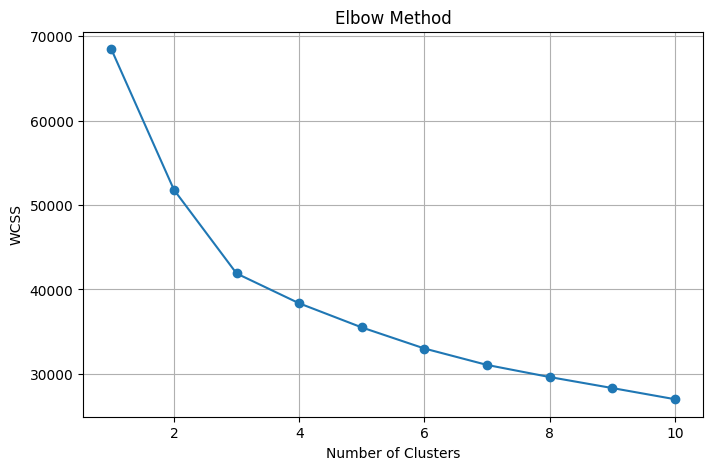

In [21]:
df = create_furnishing_type(df)

In [22]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished


In [23]:
# features

In [46]:
import pandas as pd
import ast

def luxury_score(features):

    if pd.isna(features):
        return 0

    try:
        feats = ast.literal_eval(features)

        weights = {

            # Ultra Luxury (10)
            'Golf Course': 10,
            'Private Garden / Terrace': 10,
            'Concierge Service': 10,
            'Cigar Lounge': 10,
            'Jacuzzi': 10,
            'Spa': 10,
            'Steam Room': 10,
            'Valet Parking': 10,
            'Mini Theatre': 10,
            'Theatre': 10,

            # Luxury (8)
            'Swimming Pool': 8,
            'Infinity Pool': 8,
            'Club House': 8,
            'Fitness Centre / GYM': 8,
            'Gymnasium': 8,
            'Lawn Tennis Court': 8,
            'Squash Court': 8,
            'Business Lounge': 8,
            'Banquet Hall': 8,
            'High Ceiling Height': 8,
            'Centrally Air Conditioned': 8,

            # Premium (6)
            '24x7 Security': 6,
            'Security Personnel': 6,
            'Video Door Security': 6,
            'CCTV Camera Security': 6,
            'Intercom Facility': 6,
            'Badminton Court': 6,
            'Basketball Court': 6,
            'Cricket Pitch': 6,
            'Jogging Track': 6,
            'Landscape Garden': 6,
            'Reading Lounge': 6,
            'Restaurant': 6,
            'Shopping Centre': 6,

            # Good Amenities (4)
            '24/7 Power Backup': 4,
            'Power Back up Lift': 4,
            '24/7 Water Supply': 4,
            'Park': 4,
            'Visitor Parking': 4,
            'Rain Water Harvesting': 4,
            'Water Softener Plant': 4,
            'Water purifier': 4,
            'Piped Gas': 4,
            'Gated Community': 4,
            'High Speed Elevators': 4,

            # Basic Amenities (2)
            'Lift(s)': 2,
            'Maintenance Staff': 2,
            'Water Storage': 2,
            'Security / Fire Alarm': 2,
            'Earthquake Resistant': 2,
            'Entrance Lobby': 2,
            'Internal Street Lights': 2,
            'Sewage Treatment Plant': 2,
            'Property Staff': 2,

            # Interior Quality (3)
            'Airy Rooms': 3,
            'Natural Light': 3,
            'Spacious Interiors': 3,
            'Low Density Society': 3,
            'False Ceiling Lighting': 3,
            'Recently Renovated': 3
        }

        score = sum(weights.get(feature, 1) for feature in feats)

        return score

    except:
        return 0

In [47]:
df['luxury_score'] = df['features'].apply(luxury_score)

In [48]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,luxury_score_norm,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,2.20,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,2.80,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,3.88,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,3.77,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,0.00,4.00


In [49]:
def luxury_score_normalized(features):

    if pd.isna(features):
        return 0

    try:
        feats = ast.literal_eval(features)

        score = luxury_score(features)

        return round(score / len(feats), 2)

    except:
        return 0

In [50]:
df['luxury_score_norm'] = df['features'].apply(luxury_score_normalized)

In [51]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,luxury_score_norm,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,2.20,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,2.80,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,3.88,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,3.77,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,0.00,4.00


In [52]:
import ast
import re

def get_combined_rating(rating_col):

    if pd.isna(rating_col):
        return np.nan

    try:
        ratings = ast.literal_eval(rating_col)

        values = []

        for item in ratings:

            match = re.search(r'(\d+(?:\.\d+)?)\s*out of 5', item)

            if match:
                values.append(float(match.group(1)))

        if len(values) == 0:
            return np.nan

        return round(sum(values) / len(values), 2)

    except:
        return np.nan

In [53]:
df['combined_rating'] = df['rating'].apply(get_combined_rating)

In [54]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,luxury_score_norm,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,2.20,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,2.80,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,3.88,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,3.77,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,0.00,4.00


In [55]:
df['combined_rating'].isnull().sum()

np.int64(341)

In [57]:
df.drop(columns=['nearbyLocations','furnishDetails','features','luxury_score_norm','additionalRoom','agePossession','rating'],inplace=True)

In [58]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
2782,flat,breez global hill view,sohna road,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,11.0,North,NaN,NaN,585.41,0,0,0,0,0,New Property,Unfurnished,54,4.25
2575,flat,signature global the millennia,sector 37,0.60,9230.0,650.0,Super Built up area 650(60.39 sq.m.)Carpet are...,2,2,3,7.0,NaN,650.0,NaN,596.12,0,0,0,0,0,New Property,Unfurnished,28,4.00
3413,house,u block dlf phase 3 road no 21,sector 24,1.60,29630.0,540.0,Plot area 60(50.17 sq.m.),7,5,3+,4.0,NaN,NaN,NaN,NaN,0,0,0,0,0,Old Property,Unfurnished,0,4.50
91,flat,supertech hues,sector 68,0.93,8611.0,1080.0,Carpet area: 1080 (100.34 sq.m.),2,2,2,11.0,NaN,NaN,NaN,1080.00,0,0,0,0,0,Undefined,Unfurnished,0,4.00
2333,flat,smart world gems,sector 89,0.90,8145.0,1105.0,Built Up area: 1105 (102.66 sq.m.),2,2,2,1.0,NaN,NaN,1105.0,NaN,0,0,0,0,0,Undefined,Unfurnished,26,4.00


In [59]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)